In [30]:
import numpy as np
import matplotlib.pyplot as plt


# Homework_week1_ThoiHau_DaisotuyentinhchoAI

Em chọn dữ liệu dạng text.

In [31]:
cau = ["Bun cha Ha Noi co thit nuong va nuoc mam",
       "Bun bo hue co sa te them top mo",
       "Com tam Long Xuyen suon nuong va bi cha",
       "Sua tuoi tran chau duong den ngot ngay",
       "Matcha Latte thuc uong beta",
       "Pho ga banh pho nhieu thi ngon",
       "Pizza pho mai them xuc xich",
       "Ga ran them sot cay va sot pho mai"
       ]

vocab = sorted({w for s in cau for w in s.lower().split()})
def to_vector(s):
    v = np.zeros(len(vocab))
    for w in s.lower().split():
        v[vocab.index(w)] += 1
    return v
X = np.array([to_vector(s) for s in cau])
print(X.shape)

(8, 49)


Ma trận có shape là (8,49)
- Số 8 là số câu
- Số 49 là số từ khác nhau

In [32]:
print("Shape ban dau:", X.shape)

mean_vector = X.mean(axis=0)
print("Shape cua vector trung binh theo cot:", mean_vector.shape)

X_centered = X - mean_vector
print("Shape sau khi tru trung binh:", X_centered.shape)


Shape ban dau: (8, 49)
Shape cua vector trung binh theo cot: (49,)
Shape sau khi tru trung binh: (8, 49)


In [33]:
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X

    X_norm = np.linalg.norm(X, axis=1, keepdims=True)
    Y_norm = np.linalg.norm(Y, axis=1, keepdims=True)

    Xn = X / (X_norm + 1e-12)
    Yn = Y / (Y_norm + 1e-12)

    return Xn @ Yn.T

sim_matrix = cosine_similarity(X)

print("Cosine similarity matrix:")
print(np.round(sim_matrix,3))

Cosine similarity matrix:
[[1.    0.211 0.316 0.    0.    0.    0.    0.095]
 [0.211 1.    0.    0.    0.    0.    0.136 0.101]
 [0.316 0.    1.    0.    0.    0.    0.    0.101]
 [0.    0.    0.    1.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    1.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    1.    0.272 0.302]
 [0.    0.136 0.    0.    0.    0.272 1.    0.369]
 [0.095 0.101 0.101 0.    0.    0.302 0.369 1.   ]]


In [34]:
def search(query, top_k = 3):
    q_vec = to_vector(query).reshape(1, -1)
    scores = cosine_similarity(q_vec, X).flatten()

    index = np.argsort(scores)[::-1][:top_k]

    results = []
    for i in index:
        results.append((i, cau[i], scores[i]))

    return results

query = "ga pho mai" #chon đại
results = search(query, top_k=3)

print("Query:", query)
print()

for i, sentence, score in results:
    print(f"Index: {i}")
    print(f"Sentence: {sentence}")
    print(f"Cosine score: {score:.3f}")
    print()

Query: ga pho mai

Index: 5
Sentence: Pho ga banh pho nhieu thi ngon
Cosine score: 0.577

Index: 7
Sentence: Ga ran them sot cay va sot pho mai
Cosine score: 0.522

Index: 6
Sentence: Pizza pho mai them xuc xich
Cosine score: 0.471



In [35]:
sim_no_diag = sim_matrix.copy()
np.fill_diagonal(sim_no_diag, -1)

max_index = np.unravel_index(np.argmax(sim_no_diag), sim_no_diag.shape)
min_index = np.unravel_index(np.argmin(sim_matrix), sim_matrix.shape)

print("Cap giong nhau nhat:")
print("Index:", max_index)
print(cau[max_index[0]])
print(cau[max_index[1]])
print("Cosine =", sim_matrix[max_index])

print("\nCap khac nhau nhat:")
print("Index:", min_index)
print(cau[min_index[0]])
print(cau[min_index[1]])
print("Cosine =", sim_matrix[min_index])

Cap giong nhau nhat:
Index: (np.int64(6), np.int64(7))
Pizza pho mai them xuc xich
Ga ran them sot cay va sot pho mai
Cosine = 0.3692744729377361

Cap khac nhau nhat:
Index: (np.int64(0), np.int64(3))
Bun cha Ha Noi co thit nuong va nuoc mam
Sua tuoi tran chau duong den ngot ngay
Cosine = 0.0


Nhan xet bai 1:
- Ket qua search voi "ga pho mai" cho thay cac cau co chua tu ga, pho, mai thuong co cosine cao hon
- Cap cau giong nhau nhat la cap co nhieu tu chung nhat. Cap cau khac biet nhat la cap co it hoac khong co tu chung nao nen consine thap.
- Ket qua khop voi truc giac.



In [36]:
Xc = X - X.mean(axis=0)

U, S, Vt = np.linalg.svd(Xc, full_matrices=False)

coords = U[:, :2] * S[:2]

print("Xc.shape =", Xc.shape)
print("U.shape =", U.shape)
print("S.shape =", S.shape)
print("Vt.shape =", Vt.shape)
print("coords.shape =", coords.shape)

print("\nToa do 2D cua moi cau:")
print(coords)

Xc.shape = (8, 49)
U.shape = (8, 8)
S.shape = (8,)
Vt.shape = (8, 49)
coords.shape = (8, 2)

Toa do 2D cua moi cau:
[[-1.88909373  1.04795558]
 [-0.6217689  -0.51821882]
 [-1.41648138  1.04482534]
 [-0.25491658 -2.21513423]
 [-0.15466534 -0.79504382]
 [ 1.63488381  0.16323179]
 [ 0.99438685 -0.01423154]
 [ 1.70765527  1.2866157 ]]


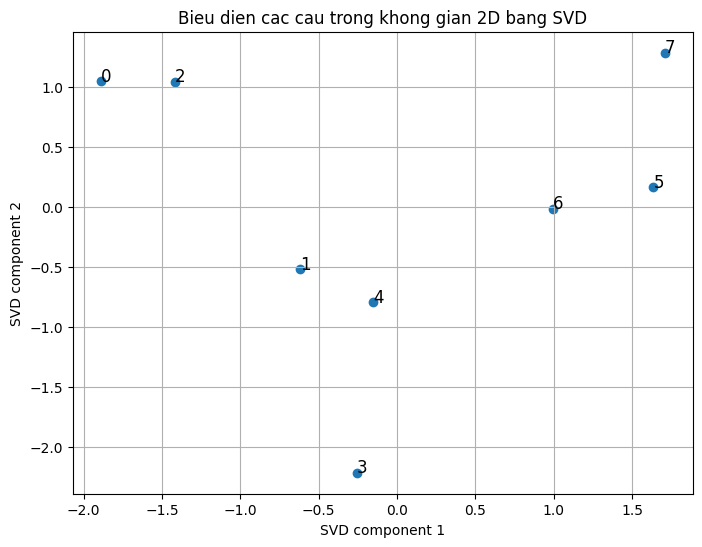

Danh sach cau:
0: Bun cha Ha Noi co thit nuong va nuoc mam
1: Bun bo hue co sa te them top mo
2: Com tam Long Xuyen suon nuong va bi cha
3: Sua tuoi tran chau duong den ngot ngay
4: Matcha Latte thuc uong beta
5: Pho ga banh pho nhieu thi ngon
6: Pizza pho mai them xuc xich
7: Ga ran them sot cay va sot pho mai


In [37]:
plt.figure(figsize=(8, 6))

plt.scatter(coords[:, 0], coords[:, 1])

for i, sentence in enumerate(cau):
    plt.text(coords[i, 0], coords[i, 1], str(i), fontsize=12)

plt.xlabel("SVD component 1")
plt.ylabel("SVD component 2")
plt.title("Bieu dien cac cau trong khong gian 2D bang SVD")
plt.grid(True)
plt.show()

print("Danh sach cau:")
for i, sentence in enumerate(cau):
    print(f"{i}: {sentence}")

Nhan xet bai 2:
- Sau khi dung SVD, moi cau duocj bieu dien bang mot diem trong khong gian 2 chieu. Cac diem duoc danh so tu 0 den 7 tuong ung voi 8 cau trong du lieu.
- Cac cau co nhieu tu chung nam gan nhau hon
- Mot so cau nam xa hon vi it tu chung voi cac cau con lai.